# ¿Cómo podemos saber si un juego va a ser un exito o no?

In [18]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

sns.set_theme(style="whitegrid")


## Carga de csv

In [19]:
df = pd.read_csv("./data/applications.csv")

/tmp/ipykernel_317182/2162864434.py:1: DtypeWarning: Columns (0: required_age) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("./data/applications.csv")


## Limpieza de datos

In [20]:
def _safe_convert_age(x) -> int:
  if pd.isna(x): return 0
  s = str(x)
  if "17+" in s: return 17
  try:
    return int(float(s)) if s != '120' else 12
  except ValueError:
    return 0
df.required_age = df["required_age"].apply(_safe_convert_age)

In [21]:
df = df.drop(columns=[
  "header_image",
  "background",
  "mat_pc_os_min",
  "mat_pc_os_rec",
  "mat_pc_processor_min",
  "mat_pc_processor_rec",
  "mat_pc_memory_min",
  "mat_pc_memory_rec",
  "mat_pc_graphics_min",
  "mat_pc_graphics_rec",
  "mat_supports_mac",
  "mat_supports_linux",
  "mat_supports_windows",
  "created_at",
  "updated_at",
  # Puede que la cantidad de logros no importe, pues al sacar el
  # juego, esto no se incluye en su debut.
  "mat_achievement_count",
  # Si bien, esto es una calificación del 1 al 10 de lo recomendado
  # que es un juego, esto no sucede cuando el juego es lanzado
  # al mercado
  # "metacritic_score",
  # "recommendations_total",
])

df["release_date"] = pd.to_datetime(
  df["release_date"],
  errors="coerce"
)

# Duplicados
df = df.drop_duplicates(subset=["appid"])

# Strings básicas
df["name"] = df["name"].astype(str).str.strip()

print(df.shape)
print(df.dtypes)

(239664, 14)
appid                             int64
name                                str
type                                str
is_free                            bool
release_date             datetime64[us]
required_age                      int64
short_description                   str
supported_languages                 str
metacritic_score                float64
recommendations_total           float64
mat_initial_price               float64
mat_final_price                 float64
mat_discount_percent            float64
mat_currency                        str
dtype: object


## Informacion rapida del dataset

In [22]:
print("\n=== INFO ===")
print(df.info())

print("\n=== DESCRIBE NUMÉRICO ===")
print(df.describe().T)

print("\n=== DESCRIBE CATEGÓRICO ===")
print(df.describe(include=["object", "category"]).T)

print("\n=== MISSING VALUES ===")
missing = (
    df.isnull()
      .mean()
      .sort_values(ascending=False)
      .mul(100)
      .round(2)
)

print(missing[missing > 0])

print("\n=== DUPLICADOS ===")
print(df.duplicated().sum())


=== INFO ===
<class 'pandas.DataFrame'>
RangeIndex: 239664 entries, 0 to 239663
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   appid                  239664 non-null  int64         
 1   name                   239660 non-null  str           
 2   type                   236997 non-null  str           
 3   is_free                239664 non-null  bool          
 4   release_date           202809 non-null  datetime64[us]
 5   required_age           239664 non-null  int64         
 6   short_description      224171 non-null  str           
 7   supported_languages    222006 non-null  str           
 8   metacritic_score       5299 non-null    float64       
 9   recommendations_total  22560 non-null   float64       
 10  mat_initial_price      144923 non-null  float64       
 11  mat_final_price        144923 non-null  float64       
 12  mat_discount_percent   144923 non-null  f

/tmp/ipykernel_317182/240987276.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(df.describe(include=["object", "category"]).T)


                      count  unique                                                top    freq
name                 239660  237757                                              Prism       6
type                 236997       5                                               game  150279
short_description    224171  206930  Embark on your adventure with player from all ...     284
supported_languages  222006   30503                                            English   54664
mat_currency         144923      33                                                USD  142570

=== MISSING VALUES ===
metacritic_score         97.79
recommendations_total    90.59
mat_initial_price        39.53
mat_final_price          39.53
mat_currency             39.53
mat_discount_percent     39.53
release_date             15.38
supported_languages       7.37
short_description         6.46
type                      1.11
dtype: float64

=== DUPLICADOS ===
0


## Verificacion de los atributos candidatos

In [23]:
target_cols = [
  "recommendations_total",
  "metacritic_score"
]

existing_targets = [c for c in target_cols if c in df.columns]

print(df[existing_targets].describe())

       recommendations_total  metacritic_score
count           2.256000e+04       5299.000000
mean            4.648429e+03         74.052651
std             4.642273e+04         10.299116
min             1.010000e+02          6.000000
25%             1.740000e+02         69.000000
50%             3.690000e+02         76.000000
75%             1.205250e+03         81.000000
max             4.661011e+06         97.000000


## Distribucion sesgada de steam

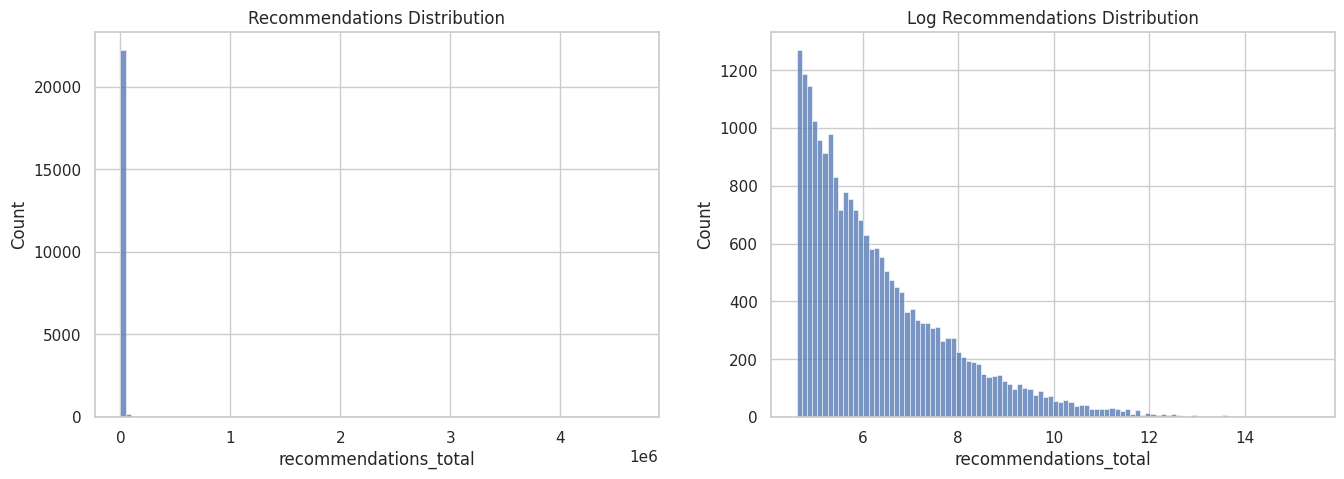

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.histplot(
    df["recommendations_total"],
    bins=100,
    ax=axes[0]
)

axes[0].set_title("Recommendations Distribution")

sns.histplot(
    np.log1p(df["recommendations_total"]),
    bins=100,
    ax=axes[1]
)

axes[1].set_title("Log Recommendations Distribution")

plt.show()

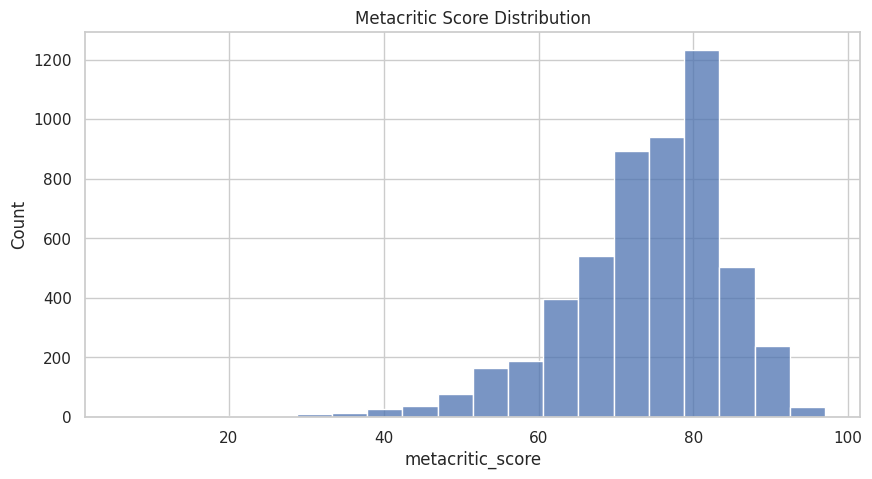

In [25]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df["metacritic_score"],
    bins=20,
)

plt.title("Metacritic Score Distribution")
plt.show()

## Nulos en el dataset

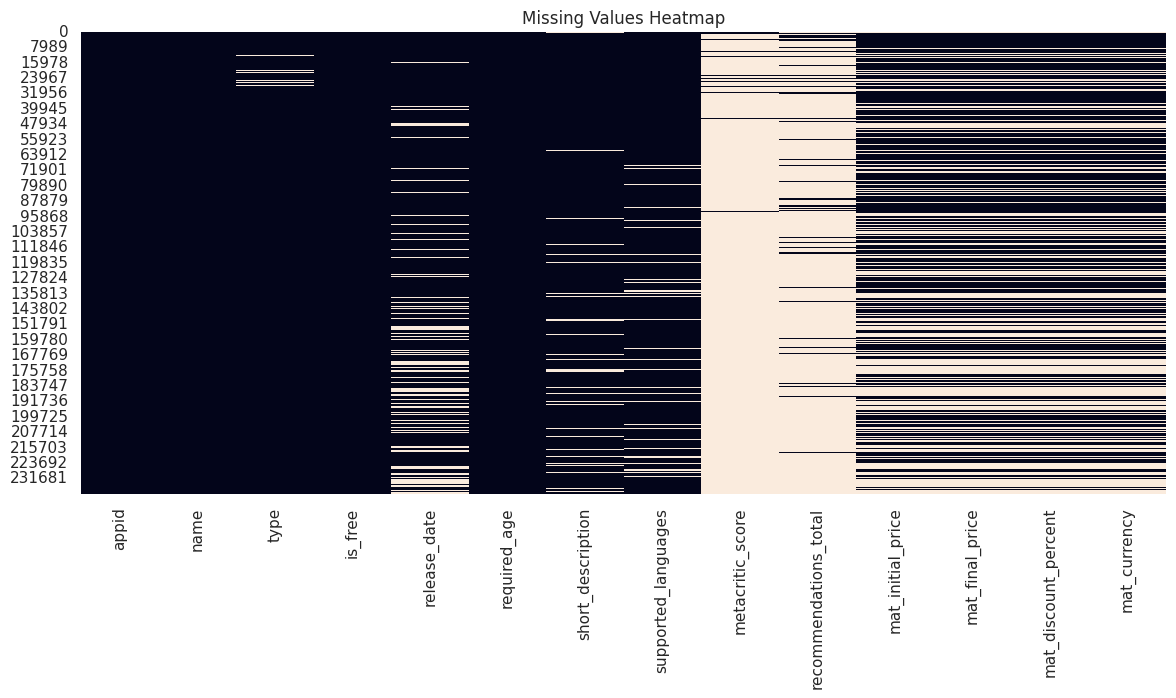

In [26]:
plt.figure(figsize=(14, 6))

sns.heatmap(
    df.isnull(),
    cbar=False,
)

plt.title("Missing Values Heatmap")
plt.show()

## Outliers en variables numericas

In [27]:
numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:

    series = df[col].dropna()

    if len(series) == 0:
        continue

    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)

    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outliers = ((series < lower) | (series > upper)).mean()

    print(f"{col}: {outliers:.2%} outliers")

appid: 0.00% outliers
required_age: 1.66% outliers
metacritic_score: 2.83% outliers
recommendations_total: 14.65% outliers
mat_initial_price: 7.63% outliers
mat_final_price: 6.93% outliers
mat_discount_percent: 9.89% outliers


## Correlaciones de pearson y de spearman a variables numericas

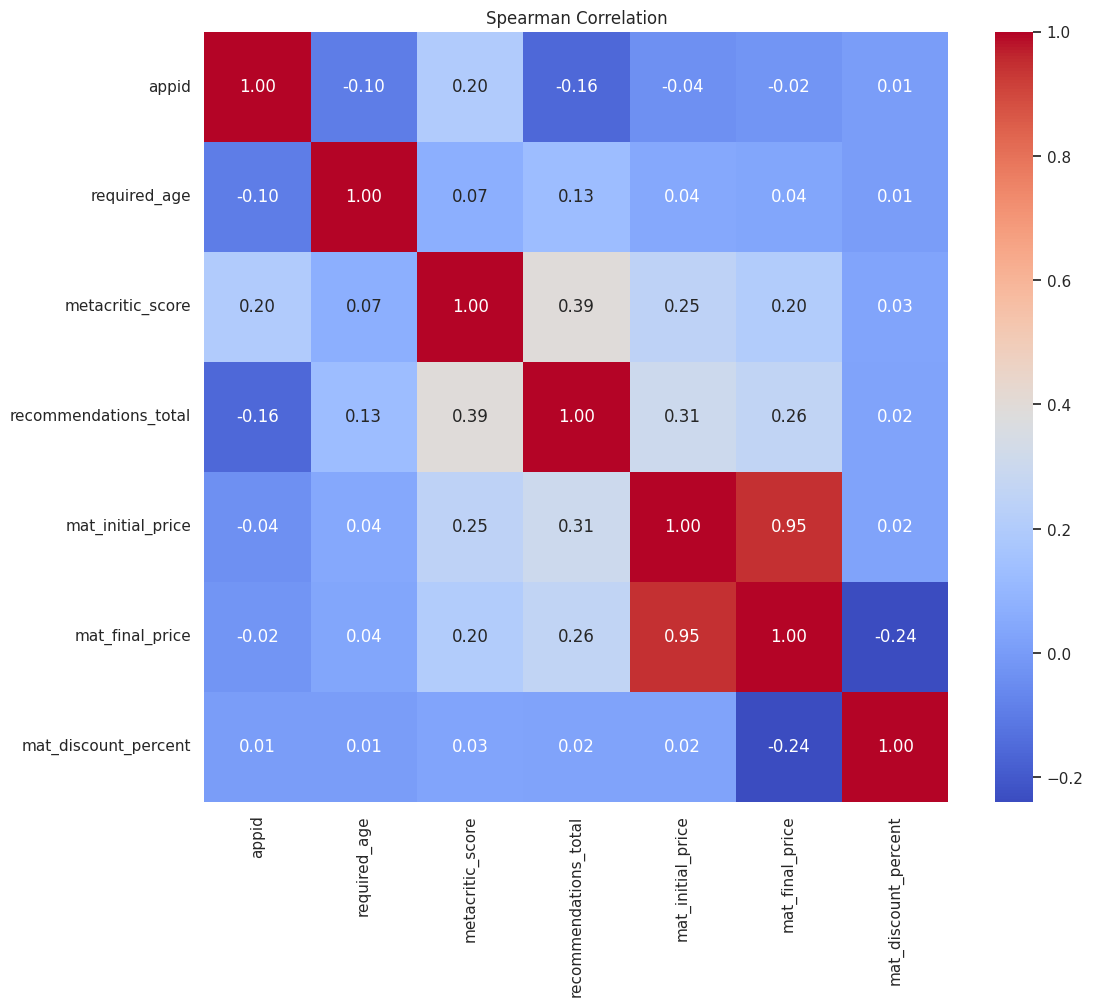

In [28]:
numeric_df = df.select_dtypes(include=np.number)

pearson_corr = numeric_df.corr(method="pearson")
spearman_corr = numeric_df.corr(method="spearman")

plt.figure(figsize=(12, 10))
sns.heatmap(
    spearman_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
)

plt.title("Spearman Correlation")
plt.show()

## Relacion entre el precio final y su exito

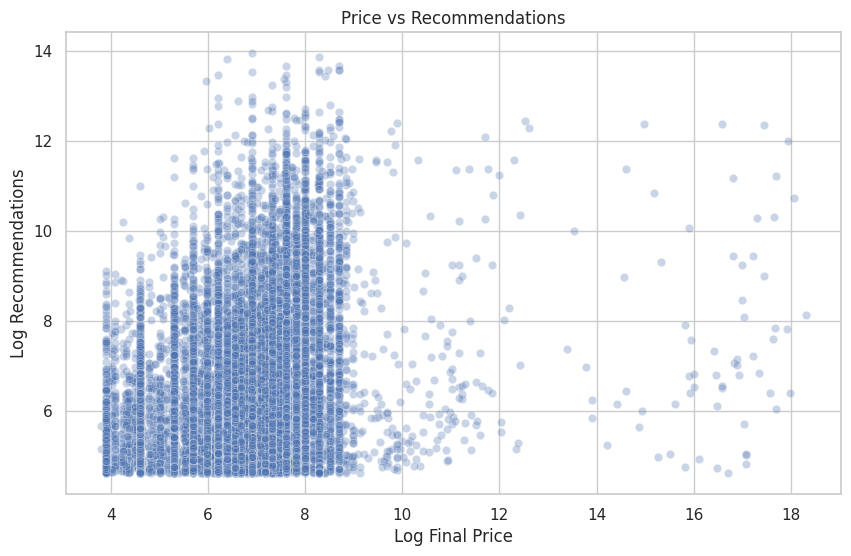

In [29]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    x=np.log1p(df["mat_final_price"]),
    y=np.log1p(df["recommendations_total"]),
    alpha=0.3
)

plt.xlabel("Log Final Price")
plt.ylabel("Log Recommendations")
plt.title("Price vs Recommendations")

plt.show()

## Free-to-play vs Paid

is_free
False    370.0
True     305.0
Name: recommendations_total, dtype: float64


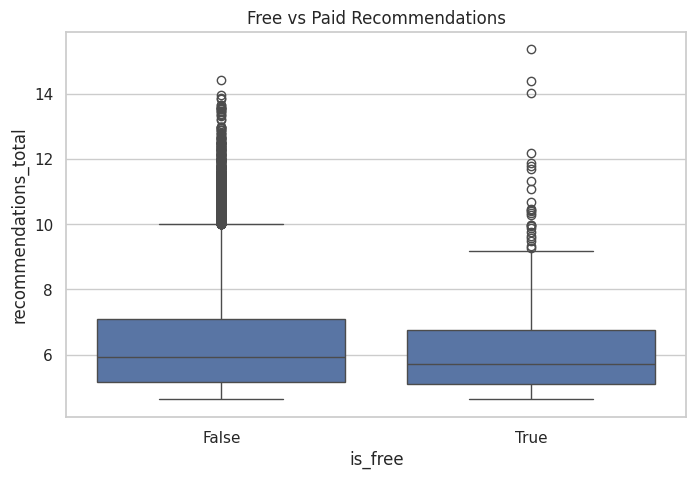

In [30]:
grouped = (
    df.groupby("is_free")["recommendations_total"]
      .median()
)

print(grouped)

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="is_free",
    y=np.log1p(df["recommendations_total"])
)

plt.title("Free vs Paid Recommendations")

plt.show()

## Juegos antiguos acumulan recomendaciones

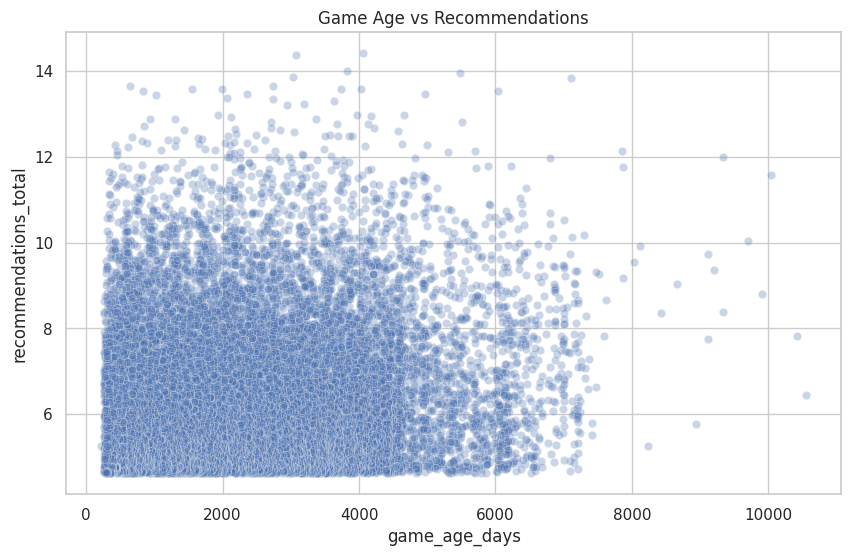

In [31]:
today = pd.Timestamp.today()

df["game_age_days"] = (
    today - df["release_date"]
).dt.days

plt.figure(figsize=(10, 6))

sns.scatterplot(
    x=df["game_age_days"],
    y=np.log1p(df["recommendations_total"]),
    alpha=0.3,
)

plt.title("Game Age vs Recommendations")

plt.show()

## Ingenieria de features

In [32]:
df["recommendations_log"] = np.log1p(
    df["recommendations_total"]
)

df["price_log"] = np.log1p(
    df["mat_final_price"]
)

df["recommendations_per_day"] = (
    df["recommendations_total"] /
    (df["game_age_days"] + 1)
)

q1 = df["recommendations_log"].quantile(0.33)
q2 = df["recommendations_log"].quantile(0.66)

def classify_success(x):
    if x <= q1:
        return "low"
    if x <= q2:
        return "medium"
    return "high"


df["success_class"] = df["recommendations_log"].apply(
    classify_success
)

print(
    df["success_class"]
      .value_counts(normalize=True)
)

success_class
high      0.937846
low       0.031198
medium    0.030956
Name: proportion, dtype: float64


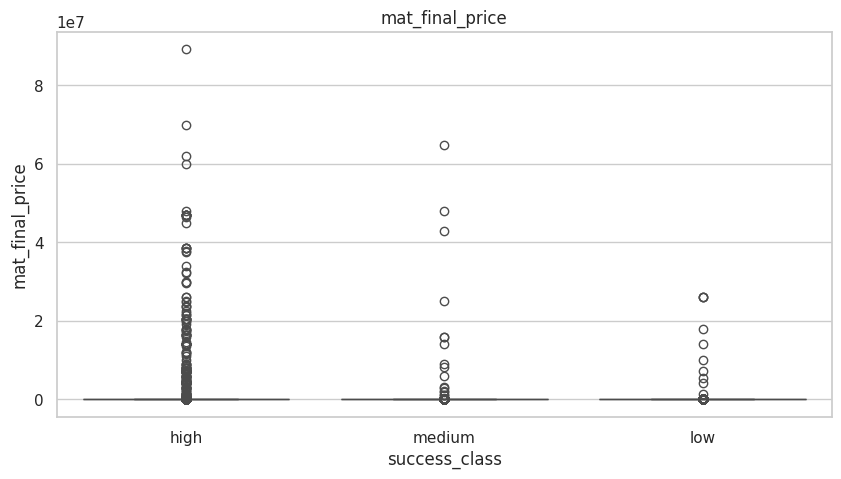

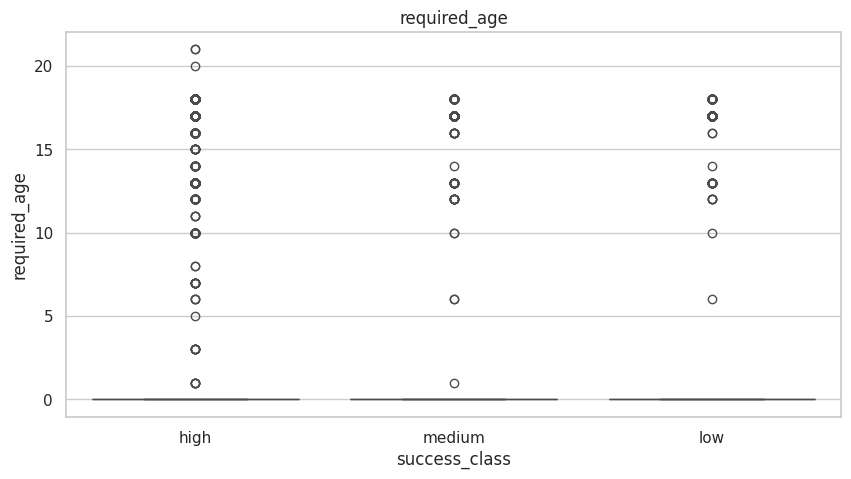

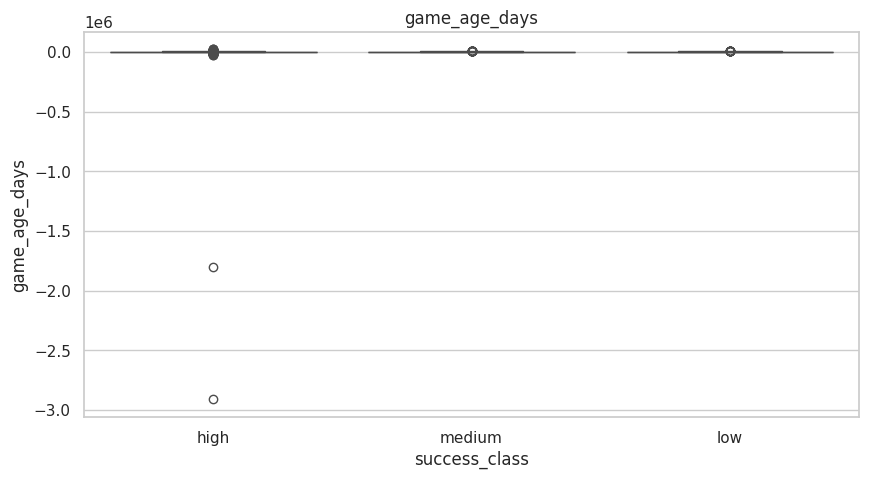

In [33]:
features = [
    "mat_final_price",
    "required_age",
    "game_age_days",
]

for feature in features:

    plt.figure(figsize=(10, 5))

    sns.boxplot(
        data=df,
        x="success_class",
        y=feature,
    )

    plt.title(feature)

    plt.show()

In [34]:
categorical_cols = df.select_dtypes(
    include=["object"]
).columns

for col in categorical_cols:

    print(f"\n=== {col} ===")
    print(df[col].nunique())

    print(df[col].value_counts().head(10))

/tmp/ipykernel_317182/1675397022.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(



=== name ===
237757
name
Prism         6
No Way Out    6
Aurora        6
Alone         6
Echoes        6
The House     5
Exodus        5
Escape        5
Bounce        5
Nightmare     5
Name: count, dtype: int64

=== type ===
5
type
game     150279
dlc       53792
demo      23521
music      8713
video       692
Name: count, dtype: int64

=== short_description ===
206930
short_description
Embark on your adventure with player from all over the world! Lead your Angel team to reveal the ancient mysteries of Galaxy…… Welcome to Angel legion, a free RPG gacha game with good fun!    284
Pixel Puzzles Ultimate, redefining digital puzzling.                                                                                                                                            155
In this DLC you find full soundtrack from the game.                                                                                                                                             130
In this DLC you will 